In [1]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning
import scipy.linalg
# Ignore ill-conditioned matrix warnings from scipy and sklearn
warnings.filterwarnings("ignore", category=scipy.linalg.LinAlgWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true.astype(np.float32), y_pred.astype(np.float32)))

class ESN:
    def __init__(self, n_input, n_reservoir, n_output,
                 spectral_radius=1.2, input_scaling=0.1,
                 leak_factor=1.0, tikhonov=1e-6,
                 connectivity=0.5, random_state=42):

        self.dtype = np.float32
        self.rng = np.random.RandomState(random_state)
        self.n_input = n_input
        self.n_reservoir = n_reservoir
        self.n_output = n_output
        self.spectral_radius = np.float32(spectral_radius)
        self.input_scaling = np.float32(input_scaling)
        self.leak_factor = np.float32(leak_factor)
        self.tikhonov = np.float32(tikhonov)
        self.connectivity = np.float32(connectivity)

        self.W_in = self.rng.uniform(-self.input_scaling, self.input_scaling,
                                     (n_reservoir, n_input)).astype(np.float32)

        W = self.rng.uniform(-1, 1, (n_reservoir, n_reservoir)).astype(np.float32)
        mask = (self.rng.rand(n_reservoir, n_reservoir) < connectivity)
        W *= mask
        eigvals = np.abs(np.linalg.eigvals(W))
        maxeig = np.max(eigvals)
        if maxeig == 0:
            maxeig = np.float32(1.0)
        self.W = ((W / maxeig) * spectral_radius).astype(np.float32)

        self.W_out = None

    def _run_reservoir(self, U, washout=0, x_init=None):
        if U is None or U.shape[0] == 0:
            x = np.zeros(self.n_reservoir, dtype=self.dtype) if x_init is None else x_init.astype(self.dtype)
            return np.zeros((0, self.n_reservoir), dtype=self.dtype), x

        U = U.astype(self.dtype)
        x = np.zeros(self.n_reservoir, dtype=self.dtype) if x_init is None else x_init.astype(self.dtype)
        states = np.zeros((U.shape[0], self.n_reservoir), dtype=self.dtype)

        for t in range(U.shape[0]):
            x = (1 - self.leak_factor) * x + self.leak_factor * np.tanh(
                self.W @ x + self.W_in @ U[t]
            )
            states[t] = x

        return states[washout:], x

    def fit(self, U_washout, U_input, Y_label):
        if U_washout is not None and U_washout.shape[0] > 0:
            _, x_wash = self._run_reservoir(U_washout, washout=0)
            states, _ = self._run_reservoir(U_input, washout=0, x_init=x_wash)
        else:
            states, _ = self._run_reservoir(U_input, washout=0, x_init=None)

        S = np.nan_to_num(states.astype(self.dtype))
        Y = np.nan_to_num(Y_label.astype(self.dtype))

        A = S.T @ S + self.tikhonov * np.eye(S.shape[1], dtype=self.dtype)
        B = S.T @ Y
        self.W_out = np.linalg.solve(A, B).astype(self.dtype)
        return self

    def predict(self, U_washout, U_input):
        if U_washout is not None and U_washout.shape[0] > 0:
            _, x_wash = self._run_reservoir(U_washout, washout=0)
            states, _ = self._run_reservoir(U_input, washout=0, x_init=x_wash)
        else:
            states, _ = self._run_reservoir(U_input, washout=0, x_init=None)

        return (states @ self.W_out).astype(self.dtype)

    def forecast_autonomous(self, washout_seq, u0, horizon):
        if washout_seq is not None and washout_seq.shape[0] > 0:
            _, x = self._run_reservoir(washout_seq, washout=0)
        else:
            x = np.zeros(self.n_reservoir, dtype=self.dtype)

        u = u0.copy().astype(self.dtype).reshape(-1)
        preds = np.zeros((horizon, self.n_output), dtype=self.dtype)

        for t in range(horizon):
            x = (1 - self.leak_factor) * x + self.leak_factor * np.tanh(
                self.W @ x + self.W_in @ u
            )
            y = (x @ self.W_out).astype(self.dtype)
            preds[t] = y
            u = y.reshape(-1)

        return preds


# ================================
# Load and prepare data
# ================================
data = np.load("lorenz63_noise_20.npy", allow_pickle=True).item()
X_soln = data["data"].astype(np.float32)
d, T_full = X_soln.shape

dt = 1.0
warmup, traintime, valtime, testtime = 500.0, 3500.0, 500.0, 500.0
warmup_pts   = int(round(warmup / dt))
traintime_pts = int(round(traintime / dt))
valtime_pts   = int(round(valtime / dt))
testtime_pts  = int(round(testtime / dt))
warmtrain_pts = warmup_pts + traintime_pts
val_end       = warmtrain_pts + valtime_pts
maxtime_pts   = int(round((warmup + traintime + valtime + testtime) / dt))

X_soln = X_soln[:, :maxtime_pts + 1]
U_rk4 = X_soln.T.astype(np.float32)

# ================================
# Data splits
# ================================
train_washout_size = warmup_pts
val_washout_size   = 500
test_washout_size  = 500

train_size = traintime_pts
val_size   = valtime_pts
test_size  = testtime_pts

train_end = train_washout_size + train_size
val_end   = train_end + val_size
test_end  = val_end + test_size

U_train_washout = U_rk4[:train_washout_size, :]
U_train_input   = U_rk4[train_washout_size:train_end, :]
U_train_label   = U_rk4[train_washout_size+1:train_end+1, :]

U_val_washout = U_rk4[train_end - val_washout_size:train_end, :]
U_val_input   = U_rk4[train_end:val_end, :]
U_val_label   = U_rk4[train_end+1:val_end+1, :]

# ================================
# Grid search parameters
# ================================
N_res_grid = [100] # fixed
rho_grid   = [0.80, 0.85, 0.90, 0.99, 1.05, 1.15, 1.25, 1.55]                    # 8
input_grid = [0.02, 0.05, 0.10, 0.20, 0.50, 0.80]                                # 6
leak_grid  = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]              # 9
tikh_grid  = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4] # 12   same as the NG-RC
conn_grid  = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]                                # 6

# 8*6*9*12*6 = 31,104

num_runs    = 5
horizons    = [25, 50, 75, 100]
window_size = 100

best_config, best_rmse = None, float("inf")
all_results = []

print("Starting grid search...")

PRINT_EVERY = 100   # <-- change this to whatever you want
counter = 0         # count grid iterations

for N_res in N_res_grid:
    for rho in rho_grid:
        for input_scaling in input_grid:
            for leak in leak_grid:
                for tikh in tikh_grid:
                    for conn in conn_grid:

                        counter += 1  # increment grid iteration count

                        all_run_rmses = {h: [] for h in horizons}
                        for run in range(num_runs):
                            seed = 2025 + run
                            esn = ESN(
                                n_input=U_train_input.shape[1],
                                n_reservoir=N_res,
                                n_output=U_train_input.shape[1],
                                spectral_radius=rho,
                                input_scaling=input_scaling,
                                leak_factor=leak,
                                tikhonov=tikh,
                                connectivity=conn,
                                random_state=seed
                            )
                            esn.fit(U_train_washout, U_train_input, U_train_label)

                            val_len = U_val_input.shape[0]
                            num_windows = val_len // window_size
                            horizon_rmses = {h: [] for h in horizons}
                            max_h = max(horizons)

                            for w in range(num_windows):
                                start = w * window_size
                                end = start + window_size
                                U_washout_window = (
                                    U_val_washout if start == 0
                                    else U_val_input[max(0, start - val_washout_size):start, :]
                                )
                                u0 = U_val_input[start, :]
                                preds = esn.forecast_autonomous(U_washout_window, u0, horizon=max_h)
                                Y_true_window = U_val_label[start:end, :]

                                for h in horizons:
                                    if h <= preds.shape[0] and h <= Y_true_window.shape[0]:
                                        rmse_h = rmse(Y_true_window[:h, :], preds[:h, :])
                                        horizon_rmses[h].append(rmse_h)

                            for h in horizons:
                                if len(horizon_rmses[h]) > 0:
                                    all_run_rmses[h].append(np.mean(horizon_rmses[h]))
                                else:
                                    all_run_rmses[h].append(np.nan)

                        mean_rmse_horizons = {h: np.nanmean(all_run_rmses[h]) for h in horizons}
                        std_rmse_horizons  = {h: np.nanstd(all_run_rmses[h])  for h in horizons}

                        # -------------------------
                        # PRINT ONLY EVERY N ITERATIONS
                        # -------------------------
                        if counter % PRINT_EVERY == 0:
                            print(
                                f"[Grid] N_res={N_res}, rho={rho}, input={input_scaling}, leak={leak}, "
                                f"tikh={tikh}, conn={conn} -> " +
                                ", ".join([
                                    f"h={h}: {mean_rmse_horizons[h]:.5f} ± {std_rmse_horizons[h]:.5f}"
                                    for h in horizons
                                ])
                            )

                        all_results.append((N_res, rho, input_scaling, leak, tikh, conn,
                                            mean_rmse_horizons, std_rmse_horizons))

                        if mean_rmse_horizons[max_h] < best_rmse:
                            best_rmse = mean_rmse_horizons[max_h]
                            best_config = (N_res, rho, input_scaling, leak, tikh, conn)

print("\nBest config:", best_config)
print(f"Best RMSE (h={max(horizons)}):", best_rmse)


Starting grid search...
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.3, tikh=0.001, conn=0.1 -> h=25: 0.79237 ± 0.01382, h=50: 0.89140 ± 0.01061, h=75: 0.89833 ± 0.00610, h=100: 0.89436 ± 0.00443
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.4, tikh=100.0, conn=0.02 -> h=25: 0.93235 ± 0.00818, h=50: 0.98998 ± 0.00355, h=75: 0.99285 ± 0.00239, h=100: 0.97969 ± 0.00170
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.6, tikh=1e-06, conn=0.2 -> h=25: 489.73263 ± 712.31484, h=50: 2161.93205 ± 1890.38785, h=75: 4096.51171 ± 3155.71304, h=100: 5262.91146 ± 3936.26513
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.7, tikh=0.1, conn=0.1 -> h=25: 0.77499 ± 0.01026, h=50: 0.88700 ± 0.00785, h=75: 0.91916 ± 0.00737, h=100: 0.92072 ± 0.00680
[Grid] N_res=100, rho=0.8, input=0.02, leak=0.8, tikh=10000.0, conn=0.02 -> h=25: 0.97012 ± 0.00045, h=50: 1.00726 ± 0.00015, h=75: 1.00452 ± 0.00010, h=100: 0.98875 ± 0.00008
[Grid] N_res=100, rho=0.8, input=0.02, leak=1.0, tikh=0.0001, conn=0.2 -> h=25: 0.60230

In [2]:
# ============================================================
# Test set predictions in 100-step independent windows (each with washout)
# ============================================================
window_size = 100
horizons = [25, 50, 75, 100]
num_runs = 25  # number of runs for ensemble

# ------------------------------------------------------------
# Test splits
# ------------------------------------------------------------
train_end = warmup_pts + traintime_pts
val_end   = train_end + valtime_pts
test_end  = val_end + testtime_pts

# Define test washout and inputs
U_test_washout = U_rk4[val_end - test_washout_size:val_end, :].astype(np.float32)
U_test_input   = U_rk4[val_end:test_end, :].astype(np.float32)

# Ground truth (noise-free data for evaluation)
data_ground_truth = np.load("lorenz63_noise_0.npy", allow_pickle=True).item()
X_soln_ground_truth = data_ground_truth["data"].astype(np.float32)
U_rk4_ground_truth = X_soln_ground_truth.T.astype(np.float32)

U_test_label = U_rk4_ground_truth[val_end + 1:test_end + 1, :].astype(np.float32)

# ------------------------------------------------------------
# Load best ESN configuration from grid search
# ------------------------------------------------------------
N_res, rho, input_scaling, leak, tikh, conn = best_config

all_run_window_rmses = {h: [] for h in horizons}
all_run_predictions = []

# ============================================================
# Run multiple seeds for ensemble averaging
# ============================================================
for run in range(num_runs):
    seed = 2025 + run
    rng = np.random.RandomState(seed)

    # Initialize ESN with best hyperparameters (float32 internal)
    esn = ESN(
        n_input=U_train_input.shape[1],
        n_reservoir=N_res,
        n_output=U_train_input.shape[1],
        spectral_radius=np.float32(rho),
        input_scaling=np.float32(input_scaling),
        leak_factor=np.float32(leak),
        tikhonov=np.float32(tikh),
        connectivity=np.float32(conn),
        random_state=seed
    )

    # Train ESN on training data (float32)
    esn.fit(
        U_train_washout.astype(np.float32),
        U_train_input.astype(np.float32),
        U_train_label.astype(np.float32)
    )

    run_predictions = []
    test_window_rmses = {h: [] for h in horizons}
    num_windows = U_test_input.shape[0] // window_size

    # ------------------------------------------------------------
    # Loop through independent test windows (each with its own washout)
    # ------------------------------------------------------------
    for w in range(num_windows):
        start = w * window_size
        end = start + window_size

        # Handle washout for each window
        if start == 0:
            # First test window — warm up using the pre-test washout segment
            U_washout_window = U_test_washout
        else:
            washout_start = max(0, start - test_washout_size)
            U_washout_window = U_test_input[washout_start:start, :]

        # Autonomous forecast
        u0 = U_test_input[start, :].astype(np.float32)
        Y_true_window = U_test_label[start:end, :].astype(np.float32)

        max_h = min(window_size, len(Y_true_window))
        preds = esn.forecast_autonomous(U_washout_window, u0, horizon=max_h)
        run_predictions.append(preds.astype(np.float32))

        # Horizon-wise RMSE
        for h in horizons:
            if h <= max_h:
                rmse_h = rmse(Y_true_window[:h], preds[:h])
                test_window_rmses[h].append(np.float32(rmse_h))

    # ------------------------------------------------------------
    # Handle last incomplete window (if any)
    # ------------------------------------------------------------
    rem = U_test_input.shape[0] % window_size
    if rem > 0:
        start_rem = U_test_input.shape[0] - rem
        washout_start = max(0, start_rem - test_washout_size)
        U_washout_window = U_test_input[washout_start:start_rem, :]

        u0 = U_test_input[start_rem, :].astype(np.float32)
        Y_true_window = U_test_label[start_rem:, :].astype(np.float32)

        preds = esn.forecast_autonomous(U_washout_window, u0, horizon=len(Y_true_window))
        run_predictions.append(preds.astype(np.float32))

        for h in horizons:
            if h <= len(Y_true_window):
                rmse_h = rmse(Y_true_window[:h], preds[:h])
                test_window_rmses[h].append(np.float32(rmse_h))

    # ------------------------------------------------------------
    # Aggregate results for this run
    # ------------------------------------------------------------
    for h in horizons:
        all_run_window_rmses[h].append(np.mean(np.array(test_window_rmses[h], dtype=np.float32)))

    all_run_predictions.append(np.vstack(run_predictions).astype(np.float32))

# ============================================================
# Summary statistics across runs
# ============================================================
mean_test_rmses = {h: np.mean(np.array(all_run_window_rmses[h], dtype=np.float32)) for h in horizons}
std_test_rmses  = {h: np.std(np.array(all_run_window_rmses[h], dtype=np.float32)) for h in horizons}

print("==== Test set RMSEs (autonomous, independent windows) ====")
for h in horizons:
    print(f"Horizon {h}: RMSE = {mean_test_rmses[h]:.5f} ± {std_test_rmses[h]:.5f}")

# Mean prediction across ensemble runs
predictions_full_mean = np.mean(np.stack(all_run_predictions).astype(np.float32), axis=0)
print("Mean predictions shape:", predictions_full_mean.shape)


==== Test set RMSEs (autonomous, independent windows) ====
Horizon 25: RMSE = 0.39844 ± 0.14227
Horizon 50: RMSE = 0.53359 ± 0.17477
Horizon 75: RMSE = 0.55297 ± 0.20063
Horizon 100: RMSE = 0.60776 ± 0.20653
Mean predictions shape: (500, 3)


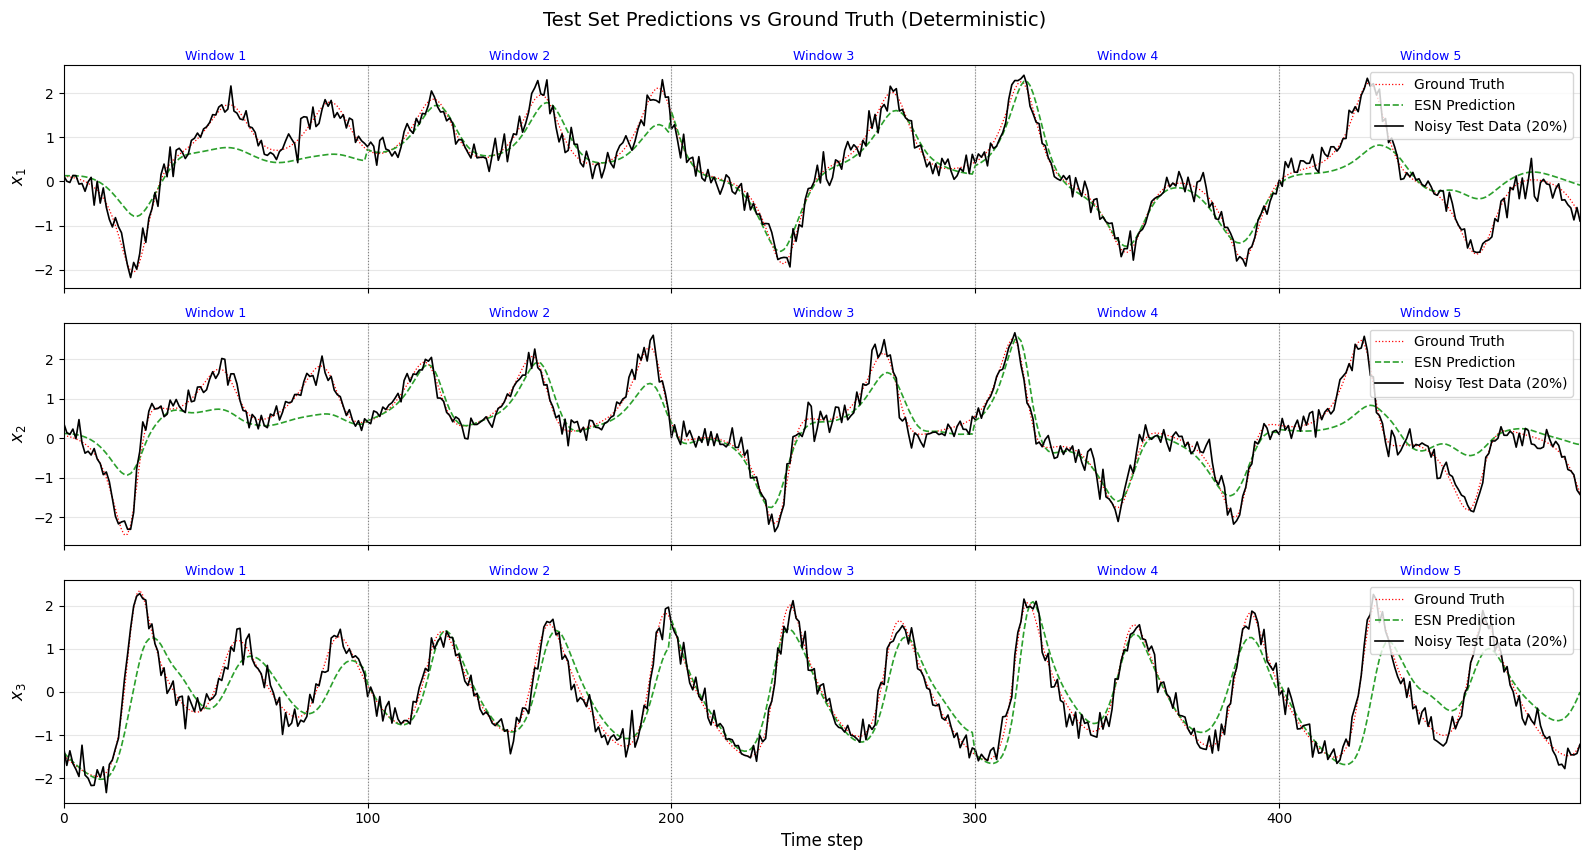

Saved plot as: Test_pred_vs_truth_allvars_ridge1.0e-02_noise0.20.png


In [3]:
import matplotlib.pyplot as plt
noise_scale=0.20
# ================================
# Concatenate predictions across windows
# ================================
U_test_Noisy = U_rk4[val_end+1:test_end+1, :]
predictions_full = predictions_full_mean  # shape (test_len, d)
true_test = U_test_label                  # ground truth

num_test_steps, d = true_test.shape
variables = [f"x_{i+1}" for i in range(d)]
num_windows = int(np.ceil(num_test_steps / window_size))

# ================================
# Plot per variable
# ================================
fig, axes = plt.subplots(d, 1, figsize=(16, 3*d), sharex=True)
if d == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    # Ground truth
    ax.plot(true_test[:, i], label="Ground Truth", color="red", linestyle=":", linewidth=0.9)

    # Predictions
    ax.plot(predictions_full[:, i], label="ESN Prediction", color='C2', linestyle='--', linewidth=1.2)

    # Noisy data
    ax.plot(U_test_Noisy[:, i], label=f"Noisy Test Data ({noise_scale*100:.0f}%)", color="black", linewidth=1.2)
    # Mark window boundaries

    for w in range(1, num_windows):
        ax.axvline(w * window_size, color="gray", linestyle="dotted", linewidth=0.8)

    # Label windows at the center
    ylim = ax.get_ylim()
    for w in range(num_windows):
        center = w * window_size + window_size // 2
        ax.text(center, ylim[1] * 1.02, f"Window {w+1}", ha="center", va="bottom", fontsize=9, color="blue")

    ax.set_ylabel(f"$x_{{{i+1}}}$", fontsize=12)
    plt.xlim(0, 499)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time step", fontsize=12)
fig.suptitle("Test Set Predictions vs Ground Truth (Deterministic)", fontsize=14, y=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.96])
filename = f"Test_pred_vs_truth_allvars_ridge{tikh:.1e}_noise{noise_scale:.2f}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot as: {filename}")


In [4]:
# ================================
# Save full predictions as .npy file
# ================================
save_info = {
    "MG_predictions_full": predictions_full.astype(np.float32),
    "true_test": true_test.astype(np.float32),
    "U_test_Noisy": U_test_Noisy.astype(np.float32),
    "noise_scale": noise_scale,
    "tikhonov": tikh,
    "spectral_radius": rho,
    "input_scaling": input_scaling,
    "leak_factor": leak,
    "connectivity": conn,
    "N_reservoir": N_res,
}

# Informative filename encoding key parameters
save_name = (
    f"L63_predictions_ESN_rho{rho:.2f}_input{input_scaling:.2f}_leak{leak:.2f}_"
    f"tikh{tikh:.1e}_conn{conn:.2f}_noise{noise_scale:.2f}_Nres{N_res}_valtestwashout{val_washout_size}.npy"
)

np.save(save_name, save_info)
print(f"Saved predictions and metadata as: {save_name}")


Saved predictions and metadata as: L63_predictions_ESN_rho0.90_input0.50_leak0.20_tikh1.0e-02_conn0.20_noise0.20_Nres100_valtestwashout500.npy
